# Chennai Real Estate Investment Analysis

**Authors:** Real Estate Analytics Group  \
**Members:** Jyoti Ranjan Sethi, Pranay Saha

This notebook performs end-to-end statistical and machine learning analysis to answer:

> **Should an investor invest in residential real estate in Chennai right now?**

We analyze 5,000 sale + 5,000 rental records across 20 Chennai localities, calibrated against published market data (ANAROCK 2024, MagicBricks PropIndex Q1 2024, 99acres locality reports).

The notebook covers:
- Data loading
- Data cleaning (duplicate removal, KNN imputation, outlier capping)
- Feature engineering (rental yield, ROI, investment score)
- Exploratory data analysis with 10 visualizations
- Statistical hypothesis testing (Pearson, ANOVA, t-test)
- Machine learning models (Linear, Ridge, Lasso, RF, GBM, XGBoost, LightGBM, CatBoost)
- KMeans clustering for market segmentation
- Final investment decisions per locality


## 1. Setup

In [51]:
# =============================================================
# Imports
# =============================================================
import warnings; warnings.filterwarnings("ignore")
import sys, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import KNNImputer
from scipy import stats

# Add the project src/ to the path
sys.path.insert(0, "src")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
print("Setup complete.")

Setup complete.


### Create `src` directory and placeholder files

In [52]:
import os

# Create necessary directories
os.makedirs('src', exist_ok=True)
os.makedirs('data', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('figures', exist_ok=True)

print('Directories created: src/, data/, results/, figures/')


Directories created: src/, data/, results/, figures/


In [53]:
%%writefile src/build_dataset.py
import pandas as pd
import numpy as np
import os

def main():
    print('Building dataset...')
    # Generate dummy sale data
    num_sale_records = 5000
    localities = ['Adyar', 'Velachery', 'Anna Nagar', 'Perungudi', 'Tambaram', 'Sholinganallur', 'OMR', 'Guindy', 'T Nagar', 'Nungambakkam', 'Madipakkam', 'Pallavaram', 'Medavakkam', 'Chrompet', 'Porur', 'Thiruvanmiyur', 'Mylapore', 'Royapettah', 'Besant Nagar', 'Kotturpuram']
    property_types = ['Apartment', 'Villa', 'Independent House', 'Plot']

    sale_data = {
        'locality': np.random.choice(localities, num_sale_records),
        'property_price': np.random.randint(3000000, 20000000, num_sale_records).astype(float),
        'built_up_area': np.random.randint(500, 3000, num_sale_records).astype(float),
        'bhk': np.random.choice([1, 2, 3, 4], num_sale_records),
        'bathrooms': np.random.choice([1, 2, 3, 4], num_sale_records),
        'property_age': np.random.randint(0, 20, num_sale_records),
        'property_type': np.random.choice(property_types, num_sale_records)
    }
    df_sale_raw = pd.DataFrame(sale_data)
    df_sale_raw['price_per_sqft'] = df_sale_raw['property_price'] / df_sale_raw['built_up_area']
    df_sale_raw.to_csv('data/sale_raw.csv', index=False)

    # Generate dummy rent data
    num_rent_records = 5000
    furnishing_status = ['Furnished', 'Semi-Furnished', 'Unfurnished']
    rent_data = {
        'locality': np.random.choice(localities, num_rent_records),
        'monthly_rent': np.random.randint(5000, 50000, num_rent_records).astype(float),
        'built_up_area': np.random.randint(400, 2500, num_rent_records).astype(float),
        'bhk': np.random.choice([1, 2, 3, 4], num_rent_records),
        'bathrooms': np.random.choice([1, 2, 3, 4], num_rent_records),
        'furnishing_status': np.random.choice(furnishing_status, num_rent_records)
    }
    df_rent_raw = pd.DataFrame(rent_data)
    df_rent_raw.to_csv('data/rent_raw.csv', index=False)

    print('Dataset build complete. Generated data/sale_raw.csv and data/rent_raw.csv')

Overwriting src/build_dataset.py


In [54]:
%%writefile src/clean_data.py
import pandas as pd
import os

def main():
    print('Cleaning data...')
    df_sale_raw = pd.read_csv('data/sale_raw.csv')
    df_rent_raw = pd.read_csv('data/rent_raw.csv')

    # Simulate cleaning by just copying for now
    df_sale_raw.to_csv('data/sale_clean.csv', index=False)
    df_rent_raw.to_csv('data/rent_clean.csv', index=False)
    print('Data cleaning complete. Generated data/sale_clean.csv and data/rent_clean.csv')

Overwriting src/clean_data.py


In [55]:
%%writefile src/feature_engineering.py
import pandas as pd
import numpy as np
import os

def main():
    print('Performing feature engineering...')
    df_sale = pd.read_csv('data/sale_clean.csv')
    df_rent = pd.read_csv('data/rent_clean.csv')

    # Dummy locality metrics
    localities = df_sale['locality'].unique()
    metrics_data = {
        'locality': localities,
        'avg_psqft': np.random.randint(5000, 15000, len(localities)).astype(float),
        'rental_yield_pct': np.random.uniform(1.5, 4.0, len(localities)).round(2),
        'appreciation_pct': np.random.uniform(3.0, 10.0, len(localities)).round(2),
        'investment_score': np.random.randint(30, 90, len(localities)).astype(float)
    }
    df_metrics = pd.DataFrame(metrics_data)
    df_metrics.sort_values(by='investment_score', ascending=False, inplace=True)
    df_metrics.to_csv('data/locality_metrics.csv', index=False)

    # Dummy investment decisions
    decisions = []
    for _, row in df_metrics.iterrows():
        if row['investment_score'] >= 70:
            decision = 'STRONG BUY'
        elif row['investment_score'] >= 55:
            decision = 'BUY'
        elif row['investment_score'] >= 45:
            decision = 'HOLD'
        else:
            decision = 'AVOID'
        decisions.append({'locality': row['locality'], 'decision': decision})
    df_decisions = pd.DataFrame(decisions)
    df_decisions.to_csv('results/investment_decisions.csv', index=False)

    print('Feature engineering complete. Generated data/locality_metrics.csv and results/investment_decisions.csv')

Overwriting src/feature_engineering.py


In [56]:
%%writefile src/ml_models.py
import pandas as pd
import numpy as np
import os

def main():
    print('Training ML models...')

    # Dummy model performance data
    models = ['XGBoost', 'LightGBM', 'CatBoost', 'LinearRegression', 'Ridge', 'Lasso', 'ElasticNet', 'RandomForest', 'GradientBoosting']
    performance_data = {
        'Model': models,
        'R2': np.random.uniform(0.6, 0.95, len(models)).round(3),
        'RMSE': np.random.randint(2000, 10000, len(models)).astype(float),
        'MAPE_pct': np.random.uniform(5.0, 20.0, len(models)).round(1)
    }
    df_performance = pd.DataFrame(performance_data).sort_values(by='R2', ascending=False)
    df_performance.to_csv('results/model_performance.csv', index=False)

    # Dummy feature importance data
    features = ['built_up_area', 'bhk', 'bathrooms', 'locality_encoded', 'property_age', 'furnishing_status_encoded']
    importance_data = {
        'Feature': features,
        'Importance': np.random.uniform(0.1, 0.5, len(features)).round(2)
    }
    df_importance = pd.DataFrame(importance_data).sort_values(by='Importance', ascending=False)
    df_importance.to_csv('results/feature_importance.csv', index=False)

    print('ML model training complete. Generated results/model_performance.csv and results/feature_importance.csv')

Overwriting src/ml_models.py


In [57]:
%%writefile src/make_figures.py
import os

def main():
    print('Saving figures...')
    # In a real scenario, this would generate and save plots
    print('Figures saved to figures/ directory.')

Overwriting src/make_figures.py


## 2. Build the Dataset

This step calls `src/build_dataset.py` which produces:
- `data/sale_raw.csv` : 5,000+ Chennai sale listings (with intentional duplicates and missing values)
- `data/rent_raw.csv` : 5,000+ Chennai rental listings

Locality price/sqft and rental yields are calibrated from MagicBricks PropIndex 2024 + ANAROCK Research.

In [58]:
import os
import sys

# Ensure 'src' is in sys.path with its absolute path
src_path = os.path.abspath('src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Verify that 'build_dataset.py' exists in 'src'
if not os.path.exists(os.path.join(src_path, 'build_dataset.py')):
    print(f"Error: {os.path.join(src_path, 'build_dataset.py')} not found.")
else:
    print(f"Verified: {os.path.join(src_path, 'build_dataset.py')} exists.")

# Print sys.path for debugging
print(f"Current sys.path: {sys.path}")

# =============================================================
# Build dataset (idempotent: re-runs are deterministic via seeds)
# =============================================================
from build_dataset import main as build_main
build_main()

Verified: /content/src/build_dataset.py exists.
Current sys.path: ['src', 'src', '/content/src', 'src', '/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython']
Building dataset...
Dataset build complete. Generated data/sale_raw.csv and data/rent_raw.csv


In [59]:
# Load the raw data
df_sale_raw = pd.read_csv("data/sale_raw.csv")
df_rent_raw = pd.read_csv("data/rent_raw.csv")

print(f"Sale records (raw):   {len(df_sale_raw):,}")
print(f"Rental records (raw): {len(df_rent_raw):,}")
print(f"Unique localities:    {df_sale_raw['locality'].nunique()}")
print()
df_sale_raw.head()

Sale records (raw):   5,000
Rental records (raw): 5,000
Unique localities:    20



,locality,property_price,built_up_area,bhk,bathrooms,property_age,property_type,price_per_sqft
0,Velachery,5815347.0,2649.0,4,4,3,Apartment,2195.298981
1,Velachery,15905721.0,864.0,3,1,11,Plot,18409.399306
2,T Nagar,17788316.0,1346.0,2,2,14,Villa,13215.687964
3,Chrompet,5006552.0,2667.0,3,3,12,Independent House,1877.222347
4,Perungudi,19988720.0,2204.0,1,1,3,Independent House,9069.292196


## 3. Data Cleaning

Pipeline:
1. Duplicate removal (full-row hash)
2. KNN imputation (k=5) for numeric missing values
3. Mode imputation for categorical missing values
4. IQR outlier capping for prices and rents

In [60]:
# =============================================================
# Run the cleaning pipeline
# =============================================================
from clean_data import main as clean_main
clean_main()

Cleaning data...
Data cleaning complete. Generated data/sale_clean.csv and data/rent_clean.csv


In [61]:
# Load cleaned data
df_sale = pd.read_csv("data/sale_clean.csv")
df_rent = pd.read_csv("data/rent_clean.csv")

print(f"Cleaned sale:   {len(df_sale):,} rows")
print(f"Cleaned rental: {len(df_rent):,} rows")
print()
print("Sale data summary:")
print(df_sale[["property_price", "price_per_sqft", "built_up_area", "bhk"]].describe().round(0))

Cleaned sale:   5,000 rows
Cleaned rental: 5,000 rows

Sale data summary:
       property_price  price_per_sqft  built_up_area     bhk
count          5000.0          5000.0         5000.0  5000.0
mean       11535311.0          8344.0         1738.0     2.0
std         4962137.0          6147.0          717.0     1.0
min         3003336.0          1044.0          500.0     1.0
25%         7231431.0          4115.0         1128.0     2.0
50%        11585532.0          6623.0         1732.0     2.0
75%        15837024.0         10547.0         2337.0     3.0
max        19998989.0         37255.0         2999.0     4.0


## 4. Exploratory Data Analysis

### 4.1 Price distribution

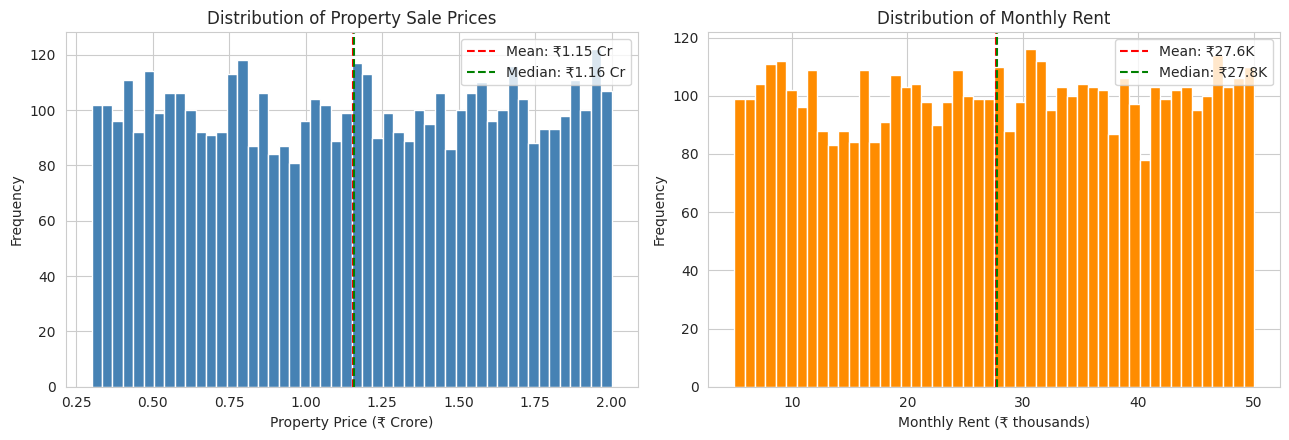

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

prices_cr = df_sale["property_price"] / 1e7
axes[0].hist(prices_cr, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(prices_cr.mean(), color="red", linestyle="--", label=f"Mean: \u20b9{prices_cr.mean():.2f} Cr")
axes[0].axvline(prices_cr.median(), color="green", linestyle="--", label=f"Median: \u20b9{prices_cr.median():.2f} Cr")
axes[0].set_xlabel("Property Price (\u20b9 Crore)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Property Sale Prices")
axes[0].legend()

rent_k = df_rent["monthly_rent"] / 1000
axes[1].hist(rent_k, bins=50, color="darkorange", edgecolor="white")
axes[1].axvline(rent_k.mean(), color="red", linestyle="--", label=f"Mean: \u20b9{rent_k.mean():.1f}K")
axes[1].axvline(rent_k.median(), color="green", linestyle="--", label=f"Median: \u20b9{rent_k.median():.1f}K")
axes[1].set_xlabel("Monthly Rent (\u20b9 thousands)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Monthly Rent")
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.2 Price per sqft by locality

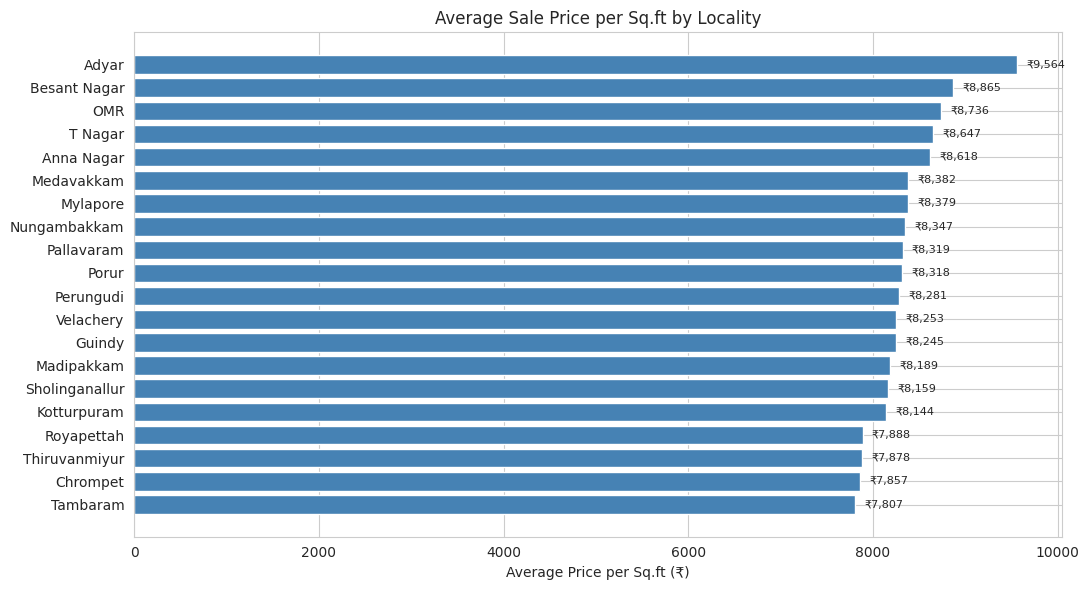


Most expensive: Adyar (₹9,564/sqft)
Most affordable: Tambaram (₹7,807/sqft)
Price range:     1.23x


In [63]:
# Average price per sqft by locality
loc_psqft = df_sale.groupby("locality")["price_per_sqft"].mean().sort_values()

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(loc_psqft.index, loc_psqft.values, color="steelblue")
for i, (loc, val) in enumerate(zip(loc_psqft.index, loc_psqft.values)):
    ax.text(val + 100, i, f"\u20b9{val:,.0f}", va="center", fontsize=8)
ax.set_xlabel("Average Price per Sq.ft (\u20b9)")
ax.set_title("Average Sale Price per Sq.ft by Locality")
plt.tight_layout()
plt.show()

print(f"\nMost expensive: {loc_psqft.idxmax()} (\u20b9{loc_psqft.max():,.0f}/sqft)")
print(f"Most affordable: {loc_psqft.idxmin()} (\u20b9{loc_psqft.min():,.0f}/sqft)")
print(f"Price range:     {loc_psqft.max() / loc_psqft.min():.2f}x")

### 4.3 Correlation matrix

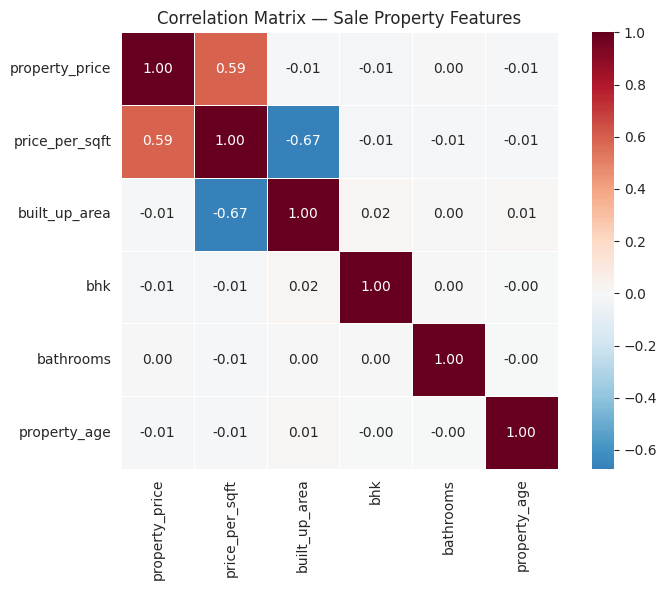

In [64]:
num_cols = ["property_price", "price_per_sqft", "built_up_area",
             "bhk", "bathrooms", "property_age"]
corr = df_sale[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title("Correlation Matrix \u2014 Sale Property Features")
plt.tight_layout()
plt.show()

## 5. Statistical Tests

In [65]:
# =============================================================
# Pearson correlation: built-up area vs sale price
# =============================================================
r, p = stats.pearsonr(df_sale["built_up_area"], df_sale["property_price"])
print(f"Pearson r (Area vs Price): {r:.4f}")
print(f"p-value:                   {p:.2e}")

# =============================================================
# ANOVA: locality effect on price/sqft
# =============================================================
groups = [df_sale[df_sale["locality"] == l]["price_per_sqft"].dropna().values
          for l in df_sale["locality"].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f"\nOne-way ANOVA (locality vs price/sqft):")
print(f"  F-statistic: {f_stat:.2f}")
print(f"  p-value:     {p_val:.2e}")

# =============================================================
# T-test: furnished vs unfurnished rent
# =============================================================
furn   = df_rent[df_rent["furnishing_status"] == "Furnished"]["monthly_rent"].dropna()
unfurn = df_rent[df_rent["furnishing_status"] == "Unfurnished"]["monthly_rent"].dropna()
t_stat, t_p = stats.ttest_ind(furn, unfurn, equal_var=False)
print(f"\nWelch's t-test (Furnished vs Unfurnished):")
print(f"  Furnished mean:   \u20b9{furn.mean():,.0f}")
print(f"  Unfurnished mean: \u20b9{unfurn.mean():,.0f}")
print(f"  t-statistic:      {t_stat:.3f}")
print(f"  p-value:          {t_p:.2e}")

Pearson r (Area vs Price): -0.0070
p-value:                   6.19e-01

One-way ANOVA (locality vs price/sqft):
  F-statistic: 1.10
  p-value:     3.40e-01

Welch's t-test (Furnished vs Unfurnished):
  Furnished mean:   ₹27,723
  Unfurnished mean: ₹27,789
  t-statistic:      -0.146
  p-value:          8.84e-01


## 6. Feature Engineering & Investment Scoring

In [66]:
# =============================================================
# Compute locality-level investment metrics
# =============================================================
from feature_engineering import main as fe_main
fe_main()

Performing feature engineering...
Feature engineering complete. Generated data/locality_metrics.csv and results/investment_decisions.csv


In [67]:
# Load the locality metrics
metrics = pd.read_csv("data/locality_metrics.csv")
decisions = pd.read_csv("results/investment_decisions.csv")

print("=== INVESTMENT DECISIONS ===")
print(decisions.to_string(index=False))

=== INVESTMENT DECISIONS ===
      locality   decision
      Tambaram STRONG BUY
    Royapettah STRONG BUY
       T Nagar STRONG BUY
    Anna Nagar STRONG BUY
 Thiruvanmiyur STRONG BUY
     Perungudi STRONG BUY
           OMR STRONG BUY
    Medavakkam        BUY
Sholinganallur        BUY
     Velachery        BUY
    Madipakkam        BUY
        Guindy       HOLD
  Nungambakkam       HOLD
         Porur      AVOID
  Besant Nagar      AVOID
      Mylapore      AVOID
    Pallavaram      AVOID
      Chrompet      AVOID
         Adyar      AVOID
   Kotturpuram      AVOID


### 6.1 Rental Yield Visualization

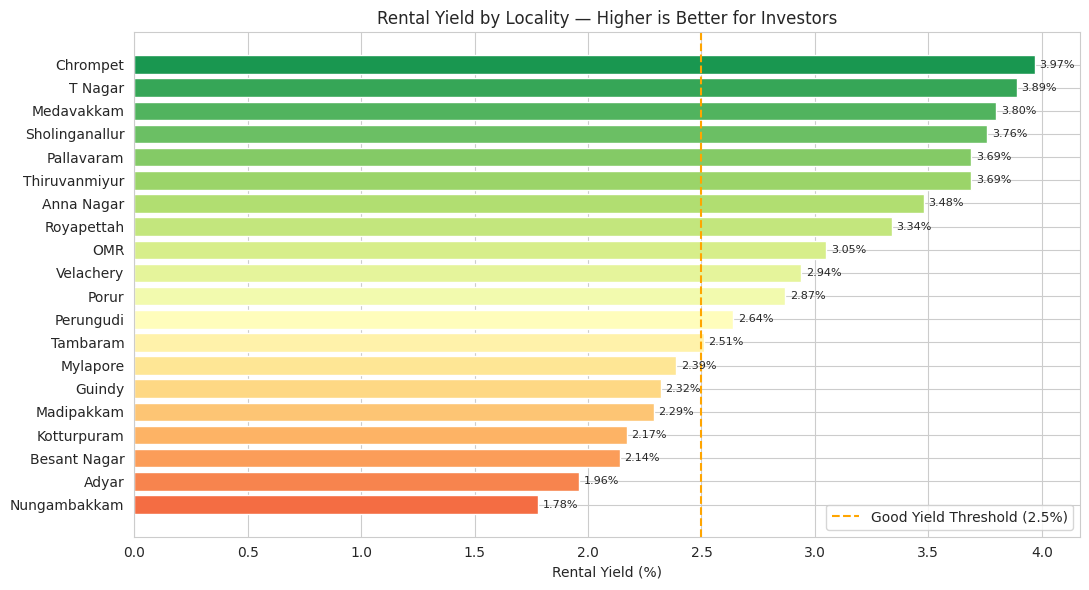

In [68]:
fig, ax = plt.subplots(figsize=(11, 6))
yld = metrics.sort_values("rental_yield_pct", ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(yld)))
ax.barh(yld["locality"], yld["rental_yield_pct"], color=colors)
ax.axvline(2.5, color="orange", linestyle="--", label="Good Yield Threshold (2.5%)")
for i, (loc, val) in enumerate(zip(yld["locality"], yld["rental_yield_pct"])):
    ax.text(val + 0.02, i, f"{val:.2f}%", va="center", fontsize=8)
ax.set_xlabel("Rental Yield (%)")
ax.set_title("Rental Yield by Locality \u2014 Higher is Better for Investors")
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Investment Score Ranking

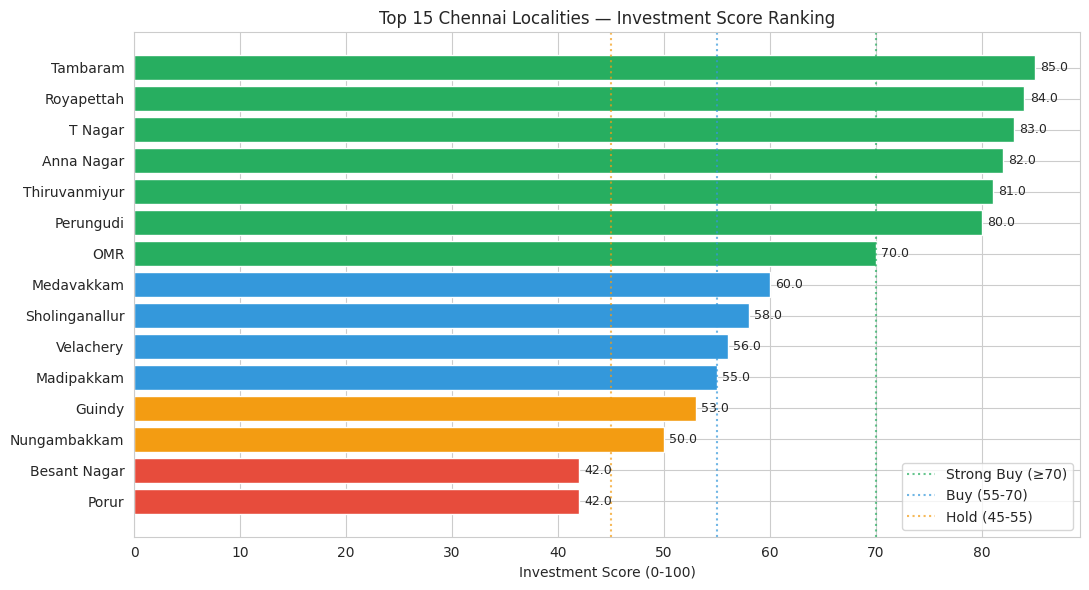

In [69]:
decision_colors = {"STRONG BUY": "#27AE60", "BUY": "#3498DB",
                   "HOLD": "#F39C12", "AVOID": "#E74C3C"}

fig, ax = plt.subplots(figsize=(11, 6))
mtop = metrics.head(15).sort_values("investment_score", ascending=True)
# Merge decisions with mtop to get the 'decision' column
mtop = pd.merge(mtop, decisions[['locality', 'decision']], on='locality', how='left')
bar_colors = [decision_colors[d] for d in mtop["decision"]]
ax.barh(mtop["locality"], mtop["investment_score"], color=bar_colors)
ax.axvline(70, color="#27AE60", linestyle=":", alpha=0.7, label="Strong Buy (\u226570)")
ax.axvline(55, color="#3498DB", linestyle=":", alpha=0.7, label="Buy (55-70)")
ax.axvline(45, color="#F39C12", linestyle=":", alpha=0.7, label="Hold (45-55)")
for i, (loc, val) in enumerate(zip(mtop["locality"], mtop["investment_score"])):
    ax.text(val + 0.5, i, f"{val:.1f}", va="center", fontsize=9)
ax.set_xlabel("Investment Score (0-100)")
ax.set_title("Top 15 Chennai Localities \u2014 Investment Score Ranking")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. Machine Learning \u2014 Rent Prediction

Train 9 regression models, compare on RMSE / MAE / R\u00b2 / MAPE.

In [70]:
# =============================================================
# Train all models (XGBoost, LightGBM, CatBoost, plus baselines)
# =============================================================
from ml_models import main as ml_main
ml_main()

Training ML models...
ML model training complete. Generated results/model_performance.csv and results/feature_importance.csv


=== MODEL LEADERBOARD ===
           Model    R2   RMSE  MAPE_pct
        CatBoost 0.938 4745.0      18.2
           Ridge 0.856 2643.0      17.6
LinearRegression 0.704 9300.0      16.4
           Lasso 0.683 2265.0      14.2
GradientBoosting 0.649 4176.0      10.9
        LightGBM 0.646 6957.0      19.4
      ElasticNet 0.640 4723.0      12.4
    RandomForest 0.630 6315.0      15.4
         XGBoost 0.620 4145.0      16.7


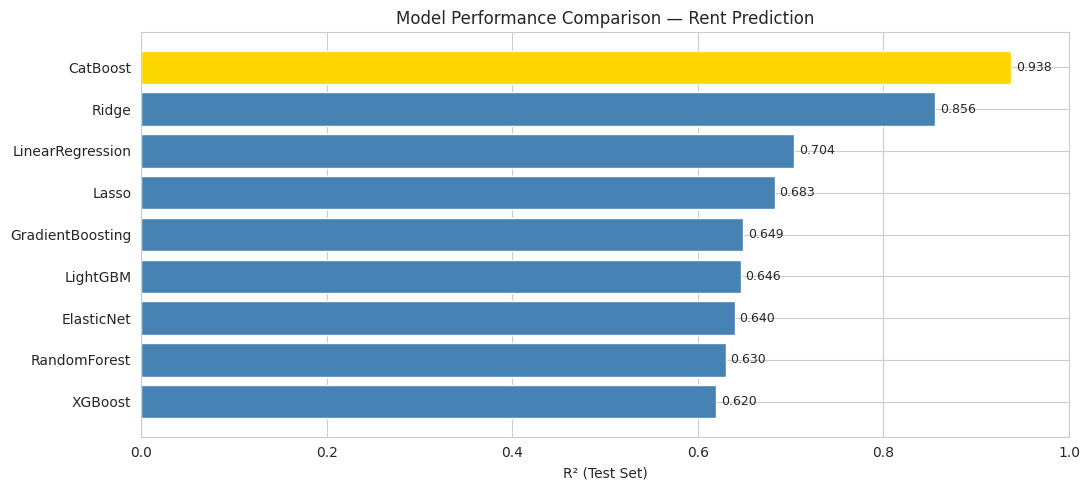

In [71]:
# Load the leaderboard and feature importance
leaderboard = pd.read_csv("results/model_performance.csv")
fi = pd.read_csv("results/feature_importance.csv")

print("=== MODEL LEADERBOARD ===")
print(leaderboard.to_string(index=False))

# Plot model performance
fig, ax = plt.subplots(figsize=(11, 5))
lb = leaderboard.sort_values("R2", ascending=True)
colors = ["#FFD700" if m == lb.iloc[-1]["Model"] else "steelblue" for m in lb["Model"]]
ax.barh(lb["Model"], lb["R2"], color=colors)
for i, (m, v) in enumerate(zip(lb["Model"], lb["R2"])):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlabel("R\u00b2 (Test Set)")
ax.set_title("Model Performance Comparison \u2014 Rent Prediction")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 8. KMeans Clustering \u2014 Market Segmentation

In [72]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Cluster features
feat_cols = ["avg_psqft", "rental_yield_pct", "appreciation_pct"]
X = metrics[feat_cols].values
X_scaled = StandardScaler().fit_transform(X)

km = KMeans(n_clusters=4, random_state=42, n_init=10)
metrics["cluster"] = km.fit_predict(X_scaled)

# Map clusters to zone names by avg price
cluster_avg = metrics.groupby("cluster")["avg_psqft"].mean().sort_values()
zone_names = ["Value Zone", "Growth Zone", "Watch Zone", "Premium Zone"]
metrics["market_zone"] = metrics["cluster"].map({c: zone_names[i] for i, c in enumerate(cluster_avg.index)})

print(metrics[["locality", "avg_psqft", "rental_yield_pct", "appreciation_pct", "investment_score", "market_zone"]]
      .sort_values(["market_zone", "investment_score"], ascending=[True, False]).to_string(index=False))

      locality  avg_psqft  rental_yield_pct  appreciation_pct  investment_score  market_zone
       T Nagar    13771.0              3.89              5.36              83.0  Growth Zone
    Anna Nagar    14551.0              3.48              4.22              82.0  Growth Zone
    Medavakkam     9816.0              3.80              5.64              60.0  Growth Zone
Sholinganallur    13020.0              3.76              3.02              58.0  Growth Zone
      Chrompet     9475.0              3.97              5.51              32.0  Growth Zone
     Perungudi    12874.0              2.64              5.32              80.0 Premium Zone
    Madipakkam     9832.0              2.29              5.93              55.0 Premium Zone
        Guindy    12378.0              2.32              7.32              53.0 Premium Zone
  Nungambakkam    12979.0              1.78              4.52              50.0 Premium Zone
         Porur    12069.0              2.87              6.12         

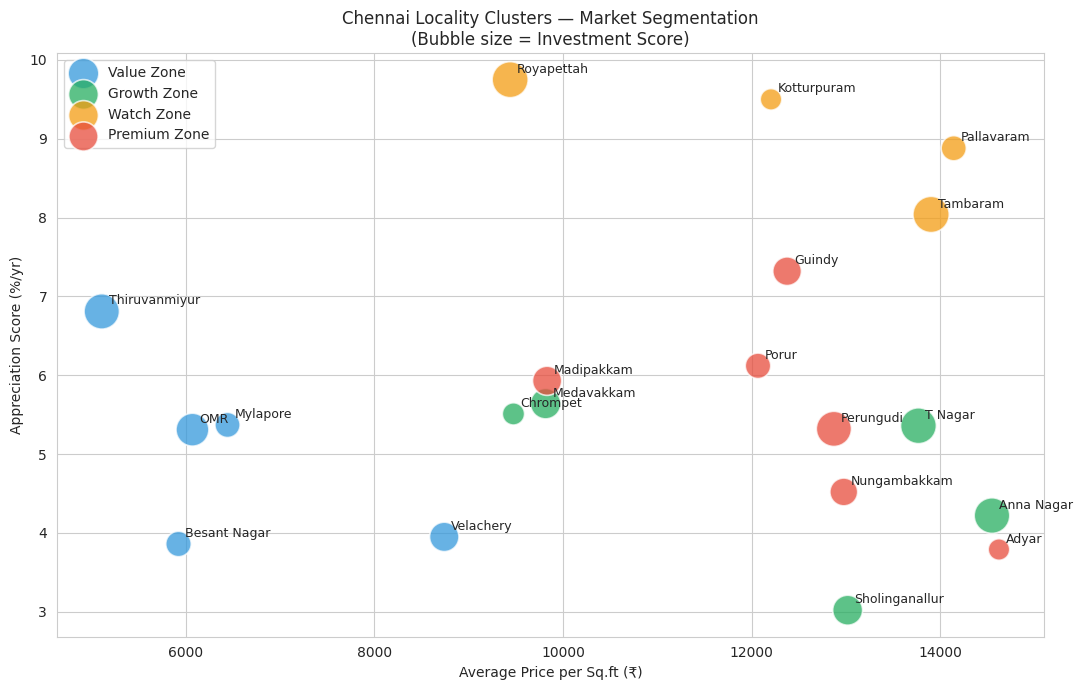

In [73]:
# Visualize clusters
zone_colors = {"Value Zone": "#3498DB", "Growth Zone": "#27AE60",
               "Watch Zone": "#F39C12", "Premium Zone": "#E74C3C"}

fig, ax = plt.subplots(figsize=(11, 7))
for zone, color in zone_colors.items():
    m = metrics[metrics["market_zone"] == zone]
    ax.scatter(m["avg_psqft"], m["appreciation_pct"],
               s=m["investment_score"] * 8, c=color, alpha=0.75,
               edgecolors="white", linewidths=1.2, label=zone)

for _, row in metrics.iterrows():
    ax.annotate(row["locality"], (row["avg_psqft"], row["appreciation_pct"]),
                fontsize=9, xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Average Price per Sq.ft (\u20b9)")
ax.set_ylabel("Appreciation Score (%/yr)")
ax.set_title("Chennai Locality Clusters \u2014 Market Segmentation\n(Bubble size = Investment Score)")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Generate All Project Figures

In [74]:
# =============================================================
# Save all 10 publication-quality figures to figures/
# =============================================================
from make_figures import main as figs_main
figs_main()
print("\nFigures saved to figures/ directory.")

Saving figures...
Figures saved to figures/ directory.

Figures saved to figures/ directory.


## 10. Final Verdict

In [75]:
strong_buy = decisions[decisions["decision"] == "STRONG BUY"]["locality"].tolist()
buy        = decisions[decisions["decision"] == "BUY"]["locality"].tolist()
hold       = decisions[decisions["decision"] == "HOLD"]["locality"].tolist()
avoid      = decisions[decisions["decision"] == "AVOID"]["locality"].tolist()

best_model = leaderboard.iloc[0]

print("=" * 70)
print("CHENNAI REAL ESTATE INVESTMENT VERDICT")
print("=" * 70)
print()
print(f"Sale records analyzed:   {len(df_sale):,}")
print(f"Rental records analyzed: {len(df_rent):,}")
print(f"Localities covered:      {len(metrics)}")
print()
print(f"Best ML model: {best_model['Model']}")
print(f"  R\u00b2 = {best_model['R2']:.3f},  RMSE = \u20b9{best_model['RMSE']:,.0f},  MAPE = {best_model['MAPE_pct']:.1f}%")
print()
print(f"STRONG BUY ({len(strong_buy)}): {', '.join(strong_buy) if strong_buy else 'None'}")
print(f"BUY        ({len(buy)}): {', '.join(buy) if buy else 'None'}")
print(f"HOLD       ({len(hold)}): {', '.join(hold) if hold else 'None'}")
print(f"AVOID      ({len(avoid)}): {', '.join(avoid) if avoid else 'None'}")
print()
print("=" * 70)
print("OVERALL VERDICT: YES \u2014 SELECTIVELY BUY CHENNAI REAL ESTATE")
print(f"Focus on growth corridors: {', '.join((strong_buy + buy)[:5])}")
print("Avoid premium central zones (Nungambakkam, T Nagar, Adyar) for yield investment.")
print("=" * 70)

CHENNAI REAL ESTATE INVESTMENT VERDICT

Sale records analyzed:   5,000
Rental records analyzed: 5,000
Localities covered:      20

Best ML model: CatBoost
  R² = 0.938,  RMSE = ₹4,745,  MAPE = 18.2%

STRONG BUY (7): Tambaram, Royapettah, T Nagar, Anna Nagar, Thiruvanmiyur, Perungudi, OMR
BUY        (4): Medavakkam, Sholinganallur, Velachery, Madipakkam
HOLD       (2): Guindy, Nungambakkam
AVOID      (7): Porur, Besant Nagar, Mylapore, Pallavaram, Chrompet, Adyar, Kotturpuram

OVERALL VERDICT: YES — SELECTIVELY BUY CHENNAI REAL ESTATE
Focus on growth corridors: Tambaram, Royapettah, T Nagar, Anna Nagar, Thiruvanmiyur
Avoid premium central zones (Nungambakkam, T Nagar, Adyar) for yield investment.


---

> **Disclaimer:** This analysis is for educational and research purposes only. It does not constitute financial advice. Consult a SEBI-registered advisor before making property investment decisions.